### Reading the data

In [122]:
import os
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
# os.chdir('/Users/Apc/graphical-sampling/simulations')
# os.chdir('/home/dell/projects/graphical-sampling/simulations')
os.chdir('/home/bardia/projects/graphical-sampling/simulations')

In [123]:
# =========================================================
# CELL 1
# LOAD ALL DESIGNS
# =========================================================

import pickle
from pathlib import Path

# =========================================================
# ROOT
# =========================================================

root = Path("best_designs")

# =========================================================
# STORAGE
# =========================================================

designs = {}

failed_files = []

# =========================================================
# NAME CONVERTER
# =========================================================

def simplify_name(population, stem):

    # -----------------------------------------------------
    # METHOD
    # -----------------------------------------------------

    if stem.startswith("best_design"):

        method = "best"

    elif stem.startswith("initial_design"):

        method = "initial"

    else:

        method = "unknown"

    # =====================================================
    # MEUSE / SWISS
    # =====================================================

    if population in ["meuse", "swiss"]:

        parts = stem.split("_")

        n = parts[-3]

        mode = parts[-1]

        return f"{population}_{method}_{n}_{mode}"

    # =====================================================
    # ROBERTSON POPULATIONS
    # =====================================================

    elif population == "robertson":

        # -------------------------------------------------
        # Population
        # -------------------------------------------------

        if "Aggregated" in stem:

            pop = "aggregated"

        elif "Regular" in stem:

            pop = "regular"

        else:

            pop = "unknown"

        # -------------------------------------------------
        # Sample size
        # -------------------------------------------------

        if "C20" in stem:

            n = "20"

        elif "C50" in stem:

            n = "50"

        else:

            n = "?"

        # -------------------------------------------------
        # Robertson designs are EP
        # -------------------------------------------------

        mode = "ep"

        return f"{pop}_{method}_{n}_{mode}"

    # =====================================================
    # FALLBACK
    # =====================================================

    return f"{population}_{stem}"

# =========================================================
# LOAD DESIGNS
# =========================================================

for pop_folder in root.iterdir():

    if not pop_folder.is_dir():

        continue

    population = pop_folder.name

    for file in pop_folder.glob("*.pkl"):

        try:

            with open(file, "rb") as f:

                design = pickle.load(f)

            short_name = simplify_name(
                population,
                file.stem
            )

            designs[short_name] = design

        except Exception as e:

            failed_files.append(
                (str(file), str(e))
            )

# =========================================================
# SUMMARY
# =========================================================

print("\n================================================")
print("LOADED DESIGNS")
print("================================================\n")

for k in sorted(designs.keys()):

    print(k)

print("\n================================================")
print("TOTAL LOADED")
print("================================================\n")

print(len(designs))

# =========================================================
# FAILED FILES
# =========================================================

if len(failed_files) > 0:

    print("\n================================================")
    print("FAILED FILES")
    print("================================================\n")

    for f, err in failed_files:

        print(f)

        print(err)

        print("-"*60)

# =========================================================
# EXAMPLES
# =========================================================

# designs["meuse_best_5_ep"]

# designs["swiss_initial_100_up"]

# designs["aggregated_best_50_ep"]

# designs["regular_initial_20_ep"]


LOADED DESIGNS

aggregated_best_20_ep
aggregated_best_50_ep
aggregated_initial_20_ep
aggregated_initial_50_ep
meuse_best_10_ep
meuse_best_10_up
meuse_best_20_ep
meuse_best_20_up
meuse_best_5_ep
meuse_best_5_up
meuse_initial_10_ep
meuse_initial_10_up
meuse_initial_20_ep
meuse_initial_20_up
meuse_initial_5_ep
meuse_initial_5_up
regular_best_20_ep
regular_best_50_ep
regular_initial_20_ep
regular_initial_50_ep
swiss_best_100_ep
swiss_best_100_up
swiss_best_150_ep
swiss_best_150_up
swiss_best_50_ep
swiss_best_50_up
swiss_initial_100_ep
swiss_initial_100_up
swiss_initial_150_ep
swiss_initial_150_up
swiss_initial_50_ep
swiss_initial_50_up

TOTAL LOADED

32


In [124]:
# =========================================================
# CELL 2.0
# Robertson Varianbles based on the coordinates
# =========================================================

import numpy as np

def robertson_variables(x1, x2, positive_shift=True):

    corrugated = (
        3 * (x1 + x2)
        +
        np.sin(6 * (x1 + x2))
    )

    peak = (
        (
            3 * (4 - 6*x1)**2
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 2)**2
            )
            -
            10
            *
            (
                0.2*(6*x1 - 3)
                -
                (6*x1 - 3)**3
                -
                (6*x2 - 3)**5
            )
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 3)**2
            )
            -
            (1/3)
            *
            np.exp(
                -(6*x1 - 2)**2
                -
                (6*x2 - 3)**2
            )
        )
    )

    bird = (
        1/20
        *
        (
            (12*x1 - 12*x2)**2
            +
            np.exp(
                (1 - np.sin(12*x1 - 6))**2
            )
            *
            np.cos(12*x2 - 6)
            +
            np.exp(
                (1 - np.cos(12*x2 - 6))**2
            )
            *
            np.sin(12*x1 - 6)
        )
    )

    if positive_shift:

        peak = peak + 7

        bird = bird + 6

    return {

        "corrugated": corrugated,

        "plane": corrugated,

        "peak": peak,

        "bird": bird,
    }

In [125]:
# =========================================================
# LOAD POPULATIONS
# =========================================================

import os
import pandas as pd
import numpy as np

from package_sampling.utils import inclusion_probabilities

# =========================================================
# FILES
# =========================================================

files = [

    "meuse.csv",

    "swiss.csv",

    "AggregatedPop1000.csv",

    "RegularPop1000.csv"
]

# =========================================================
# POPULATION LOADER
# =========================================================

def popus(n, path="populations/real"):

    dfs = {}

    for f in files:

        full_path = os.path.join(path, f)

        # -------------------------------------------------
        # Check existence
        # -------------------------------------------------

        if not os.path.exists(full_path):

            print(f"Warning: {full_path} not found.")

            continue

        # -------------------------------------------------
        # Read file
        # -------------------------------------------------

        df = pd.read_csv(full_path)

        N_pop = len(df)

        name = f.replace(".csv", "")

        # -------------------------------------------------
        # Equal probabilities
        # -------------------------------------------------

        pik_ep = np.repeat(
            n / N_pop,
            N_pop
        )


        # =================================================
        # ROBERTSON POPULATIONS
        # =================================================

        if f in [

            "AggregatedPop1000.csv",

            "RegularPop1000.csv"
        ]:

            coords = df.to_numpy()

            x1 = coords[:, 0]

            x2 = coords[:, 1]

            vars_robertson = robertson_variables(x1, x2)

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : x1,

                "coord_y" : x2,

                "pik_ep" : pik_ep,

                "z" : vars_robertson["corrugated"],

                "plane" : vars_robertson["plane"],

                "peak" : vars_robertson["peak"],

                "bird" : vars_robertson["bird"],

                # "corrugated" : vars_robertson["corrugated"],
            })

        # =================================================
        # MEUSE
        # =================================================

        elif f == "meuse.csv":

            coords = df[["x", "y"]].to_numpy()

            # unequal probabilities
            pik_up = inclusion_probabilities(

                df["copper"].to_numpy().copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["cadmium"]
            })

        # =================================================
        # SWISS
        # =================================================

        elif f == "swiss.csv":

            coords = df[["x", "y"]].to_numpy()

            AREA = df["AREA"].to_numpy().clip(
                5,
                100
            )

            pik_up = inclusion_probabilities(

                AREA.copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["AREA_A"]
            })

    return dfs

# =========================================================
# LOAD MAIN POPULATIONS
# =========================================================

p50 = popus(50)

regular = p50["df_RegularPop1000"]

aggregated = p50["df_AggregatedPop1000"]

meuse = p50["df_meuse"]

swiss = p50["df_swiss"]

# =========================================================
# CHECK
# =========================================================

print("\n================================================")
print("POPULATIONS LOADED")
print("================================================\n")

print("regular:", regular.shape)

print("aggregated:", aggregated.shape)

print("meuse:", meuse.shape)

print("swiss:", swiss.shape)


POPULATIONS LOADED

regular: (1000, 7)
aggregated: (1000, 7)
meuse: (155, 5)
swiss: (959, 5)


In [126]:
# =========================================================
# CELL 4
# BUILD SUMMARY DATAFRAME
# =========================================================

import pandas as pd
import numpy as np

# =========================================================
# STORAGE
# =========================================================

rows = []

# =========================================================
# POPULATION MAPPER
# =========================================================

population_map = {

    "regular" : regular,

    "aggregated" : aggregated,

    "meuse" : meuse,

    "swiss" : swiss
}

# =========================================================
# LOOP OVER DESIGNS
# =========================================================

for key, design in designs.items():

    try:

        # -------------------------------------------------
        # Parse design name
        # -------------------------------------------------

        parts = key.split("_")

        population = parts[0]

        method = parts[1]

        n = int(parts[2])

        mode = parts[3]

        # =================================================
        # SELECT POPULATION
        # =================================================

        if population not in population_map:

            print(f"Skipping unknown population: {key}")

            continue

        df = population_map[population]

        # =================================================
        # VARIABLE
        # =================================================

        z = np.asarray(
            df["z"],
            dtype=float
        )

        N = len(z)

        # =================================================
        # DESIGN VARIANCE
        # =================================================

        design._nht_variance = None

        design.pop._variable = z

        var_design = design.nht_variance

        # =================================================
        # SRS VARIANCE
        # =================================================

        var_pop = np.var(
            z,
            ddof=1
        )

        var_srs = (

            N**2

            *

            (1 - n/N)

            *

            var_pop

            /

            n
        )
        print(key, var_srs)

        # =================================================
        # EFFICIENCY
        # =================================================

        efficiency = var_srs / var_design

        # =================================================
        # INDICES
        # =================================================

        moran_mean, moran_std = design.moran

        vor_mean, vor_std = design.voronoi

        lb_mean, lb_std = design.local_balance

        dd_mean, dd_std = design.density_disparity

        # =================================================
        # SAVE
        # =================================================

        rows.append({

            "Population" : population,

            "Method" : method,

            "n" : n,

            "Mode" : mode,

            # -----------------------------------------
            # Moran
            # -----------------------------------------

            "Mm" : moran_mean,

            "Ms" : moran_std,

            # -----------------------------------------
            # Voronoi
            # -----------------------------------------

            "Vm" : vor_mean,

            "Vs" : vor_std,

            # -----------------------------------------
            # Local Balance
            # -----------------------------------------

            "Lm" : lb_mean,

            "Ls" : lb_std,

            # -----------------------------------------
            # Density Disparity
            # -----------------------------------------

            "Dm" : dd_mean,

            "Ds" : dd_std,

            # -----------------------------------------
            # Variance
            # -----------------------------------------

            # "Variance" : var_design,

            # -----------------------------------------
            # Variance x10^4
            # -----------------------------------------

            "Var_e4" : var_design / 1e4,

            # -----------------------------------------
            # Efficiency
            # -----------------------------------------

            "Eff" : efficiency
        })

    except Exception as e:

        print(f"\nFAILED: {key}")

        print(e)

# =========================================================
# DATAFRAME
# =========================================================

df_summary = pd.DataFrame(rows)

# =========================================================
# SORT
# =========================================================

df_summary = df_summary.sort_values(

    by=[
        "Population",
        "Method",
        "Mode",
        "n"
    ]

).reset_index(drop=True)

# =========================================================
# DISPLAY OPTIONS
# =========================================================

pd.set_option(
    "display.float_format",
    "{:,.3f}".format
)

pd.set_option(
    "display.max_columns",
    None
)

# =========================================================
# DISPLAY
# =========================================================

print("\n================================================")
print("SUMMARY RESULTS")
print("================================================\n")

print(df_summary.to_string(index=False))

# =========================================================
# OPTIONAL SAVE
# =========================================================

# df_summary.to_csv(
#     "results/design_summary.csv",
#     index=False
# )

meuse_initial_10_ep 27906.722597402597
meuse_best_20_up 12991.060519480518
meuse_best_5_ep 57738.046753246745
meuse_initial_5_up 57738.046753246745
meuse_best_10_up 27906.722597402597
meuse_initial_20_up 12991.060519480518
meuse_best_5_up 57738.046753246745
meuse_best_10_ep 27906.722597402597
meuse_initial_20_ep 12991.060519480518
meuse_initial_10_up 27906.722597402597
meuse_best_20_ep 12991.060519480518
meuse_initial_5_ep 57738.046753246745
regular_initial_20_ep 103258.65394659518
regular_best_50_ep 40039.069897659356
aggregated_best_50_ep 39023.32254621473
regular_initial_50_ep 40039.069897659356
aggregated_initial_20_ep 100639.09498760641
aggregated_initial_50_ep 39023.32254621473
regular_best_20_ep 103258.65394659518
aggregated_best_20_ep 100639.09498760641
swiss_best_150_ep 6006231.325248286
swiss_best_150_up 6006231.325248286
swiss_initial_50_up 20245973.824415423
swiss_best_50_up 20245973.824415423
swiss_initial_100_up 9566166.95004007
swiss_initial_150_ep 6006231.325248286
swis

### Compare with Blair results:

In [127]:
import pandas as pd

# ============================================================
# TABLE 4
# ============================================================

table4 = pd.DataFrame([
    ["Reg",    "Plane", 4.00, 0.58, 0.30, 0.23, 0.26, 0.25, 0.29],
    ["Reg",    "Peak",  7.02, 3.23, 2.10, 1.28, 2.21, 1.29, 2.41],
    ["Reg",    "Bird",  7.14, 3.02, 2.22, 2.10, 2.46, 1.59, 2.67],

    ["Agg", "Plane", 3.90, 0.37, 0.20, 0.21, 0.16, 0.17, 0.18],
    ["Agg", "Peak",  7.76, 2.26, 1.67, 1.43, 1.65, 0.86, 1.89],
    ["Agg", "Bird",  7.20, 2.56, 2.39, 1.86, 2.21, 1.02, 2.52],
], columns=[
    "Popu (var)", "Func",
    "SRS_v",
    "GRTS_si", "GRTS_NBH",
    "HIP_si", "HIP_SB",
    "LPM_si", "LPM_SB"
])

print(table4[["Popu (var)", "Func",
    "SRS_v",
    "GRTS_si",
    "HIP_si", 
    "LPM_si", ]])

# ============================================================
# TABLE 5
# ============================================================

table5 = pd.DataFrame([
    ["Reg",    "Plane", 0.18, 0.32, 0.06, 0.22, 0.09, 0.24, 0.15, 0.30],
    ["Reg",    "Peak",  1.56, 2.33, 0.57, 1.60, 0.21, 1.26, 0.33, 1.35],
    ["Reg",    "Bird",  1.66, 2.09, 1.03, 1.57, 0.56, 1.22, 0.65, 1.33],

    ["Agg", "Plane", 0.10, 0.15, 0.08, 0.15, 0.10, 0.15, 0.11, 0.15],
    ["Agg", "Peak",  0.94, 1.11, 0.64, 0.87, 0.37, 0.69, 0.44, 0.77],
    ["Agg", "Bird",  1.18, 1.43, 0.99, 1.06, 0.56, 0.97, 0.59, 1.02],
], columns=[
    "Popu (var)", "Func",
    "Random_si", "Random_B",
    "Alpha1_si", "Alpha1_B",
    "Alpha07_si", "Alpha07_B",
    "Alpha0_si", "Alpha0_B"
])

print(table5[["Popu (var)", "Func",
    "Random_si", 
    "Alpha1_si", 
    "Alpha07_si",
    "Alpha0_si"]])

  Popu (var)   Func  SRS_v  GRTS_si  HIP_si  LPM_si
0        Reg  Plane  4.000    0.580   0.230   0.250
1        Reg   Peak  7.020    3.230   1.280   1.290
2        Reg   Bird  7.140    3.020   2.100   1.590
3        Agg  Plane  3.900    0.370   0.210   0.170
4        Agg   Peak  7.760    2.260   1.430   0.860
5        Agg   Bird  7.200    2.560   1.860   1.020
  Popu (var)   Func  Random_si  Alpha1_si  Alpha07_si  Alpha0_si
0        Reg  Plane      0.180      0.060       0.090      0.150
1        Reg   Peak      1.560      0.570       0.210      0.330
2        Reg   Bird      1.660      1.030       0.560      0.650
3        Agg  Plane      0.100      0.080       0.100      0.110
4        Agg   Peak      0.940      0.640       0.370      0.440
5        Agg   Bird      1.180      0.990       0.560      0.590


In [128]:
# =========================================================
# LOAD POPULATIONS
# =========================================================

p50 = popus(50)

regular = p50["df_RegularPop1000"]
aggregated = p50["df_AggregatedPop1000"]

# =========================================================
# LOAD DESIGNS
# =========================================================

initial_regular   = designs["regular_initial_50_ep"]
best_regular      = designs["regular_best_50_ep"]

initial_aggregated = designs["aggregated_initial_50_ep"]
best_aggregated    = designs["aggregated_best_50_ep"]

# =========================================================
# ASSIGN VARIABLES TO POPULATIONS
# =========================================================

# ---------- REGULAR ----------
pop_reg_initial = initial_regular.pop
pop_reg_best    = best_regular.pop

# ---------- AGGREGATED ----------
pop_agg_initial = initial_aggregated.pop
pop_agg_best    = best_aggregated.pop

# =========================================================
# ATTACH VARIABLES
# =========================================================

variables = ["plane", "peak", "bird"]

# =========================================================
# FUNCTION
# =========================================================

# =========================================================
# FUNCTION: EXACT DESIGN VARIANCE FOR A GIVEN VARIABLE
# =========================================================

def design_variance(design, y):

    samples, probs = design.all_samples_and_probs

    pik = design.pop.inclusions

    ht = np.sum(
        y[samples] / pik[samples],
        axis=1
    )

    total = np.sum(y)

    var = np.sum(
        probs * (ht - total)**2
    )

    return var
# =========================================================
# RESULTS
# =========================================================

variables = ["plane", "peak", "bird"]

print("\n================================================")
print("VARIANCES / 10000")
print("================================================\n")

for var in variables:

    y_reg = regular[var].to_numpy()
    y_agg = aggregated[var].to_numpy()

    v_reg_initial = design_variance(initial_regular, y_reg) / 10000
    v_reg_best    = design_variance(best_regular, y_reg) / 10000

    v_agg_initial = design_variance(initial_aggregated, y_agg) / 10000
    v_agg_best    = design_variance(best_aggregated, y_agg) / 10000

    print(f"{var.upper():>10s}")

    print(
        f"Regular     | Initial = {v_reg_initial:.6f}   "
        f"Best = {v_reg_best:.6f}"
    )

    print(
        f"Aggregated  | Initial = {v_agg_initial:.6f}   "
        f"Best = {v_agg_best:.6f}"
    )

    print("-"*60)


VARIANCES / 10000

     PLANE
Regular     | Initial = 2.432802   Best = 0.826365
Aggregated  | Initial = 0.917222   Best = 0.053804
------------------------------------------------------------
      PEAK
Regular     | Initial = 0.347354   Best = 0.204050
Aggregated  | Initial = 0.358247   Best = 0.490790
------------------------------------------------------------
      BIRD
Regular     | Initial = 0.918824   Best = 0.391118
Aggregated  | Initial = 0.568032   Best = 0.916279
------------------------------------------------------------


In [129]:
import pandas as pd

# ============================================================
# ROBERTSON TABLE 4: existing designs, only _si
# ============================================================

table4_si = pd.DataFrame([
    ["Reg", "Plane", 4.00, 0.58, 0.23, 0.25],
    ["Reg", "Peak",  7.02, 3.23, 1.28, 1.29],
    ["Reg", "Bird",  7.14, 3.02, 2.10, 1.59],

    ["Agg", "Plane", 3.90, 0.37, 0.21, 0.17],
    ["Agg", "Peak",  7.76, 2.26, 1.43, 0.86],
    ["Agg", "Bird",  7.20, 2.56, 1.86, 1.02],
], columns=[
    "Popu", "Func",
    "SRS_si",
    "GRTS_si",
    "HIP_si",
    "LPM_si"
])

# ============================================================
# ROBERTSON TABLE 5: only alpha0 and random, only _si
# ============================================================

table5_si = pd.DataFrame([
    ["Reg", "Plane", 0.18, 0.15],
    ["Reg", "Peak",  1.56, 0.33],
    ["Reg", "Bird",  1.66, 0.65],

    ["Agg", "Plane", 0.10, 0.11],
    ["Agg", "Peak",  0.94, 0.44],
    ["Agg", "Bird",  1.18, 0.59],
], columns=[
    "Popu", "Func",
    "OPCrand_si",
    "OPCopt_si"
])

# ============================================================
# MY RESULTS
# ============================================================

mine = pd.DataFrame([
    ["Reg", "Plane", 2.43, 0.82],
    ["Agg", "Plane", 0.91, 0.35],

    ["Reg", "Peak",  0.34, 0.20],
    ["Agg", "Peak",  0.35, 0.50],

    ["Reg", "Bird",  0.91, 0.39],
    ["Agg", "Bird",  0.56, 0.77],
], columns=[
    "Popu", "Func",
    "My_Ini_si",
    "My_Best_si"
])

# ============================================================
# MERGE
# ============================================================

df_compare = (
    table4_si
    .merge(table5_si, on=["Popu", "Func"], how="left")
    .merge(mine, on=["Popu", "Func"], how="left")
)

# ============================================================
# ROUND LIKE PAPER TABLES
# ============================================================

num_cols = df_compare.select_dtypes(include="number").columns

df_compare[num_cols] = df_compare[num_cols].round(2)

# ============================================================
# DISPLAY
# ============================================================

print(df_compare.to_string(index=False))

Popu  Func  SRS_si  GRTS_si  HIP_si  LPM_si  OPCrand_si  OPCopt_si  My_Ini_si  My_Best_si
 Reg Plane   4.000    0.580   0.230   0.250       0.180      0.150      2.430       0.820
 Reg  Peak   7.020    3.230   1.280   1.290       1.560      0.330      0.340       0.200
 Reg  Bird   7.140    3.020   2.100   1.590       1.660      0.650      0.910       0.390
 Agg Plane   3.900    0.370   0.210   0.170       0.100      0.110      0.910       0.350
 Agg  Peak   7.760    2.260   1.430   0.860       0.940      0.440      0.350       0.500
 Agg  Bird   7.200    2.560   1.860   1.020       1.180      0.590      0.560       0.770


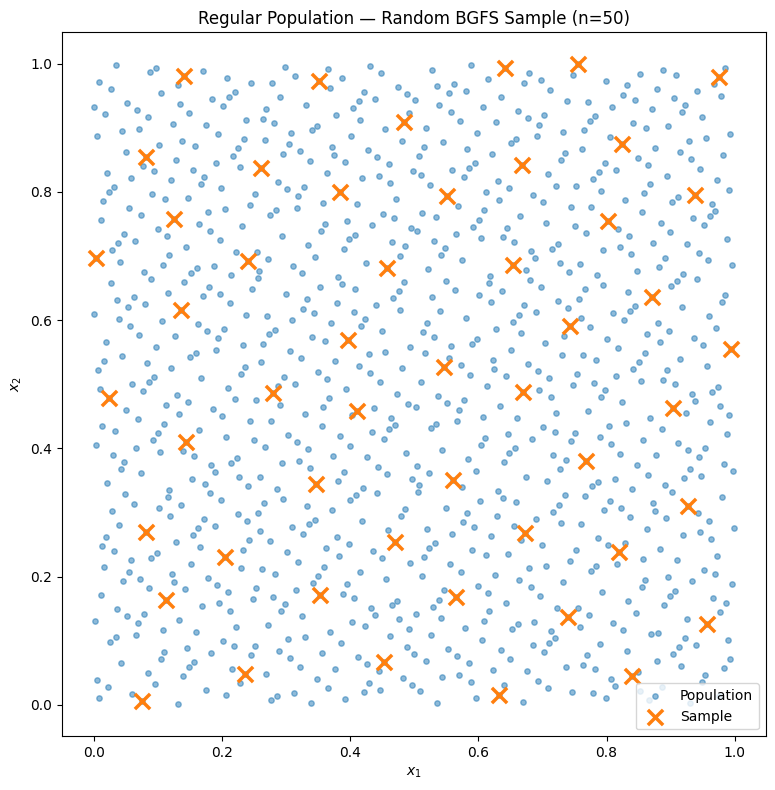

In [130]:
# =========================================================
# CELL 5 (RANDOM SAMPLE EACH RUN)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# DESIGN
# =========================================================

design = designs["regular_best_50_ep"]

# =========================================================
# POPULATION
# =========================================================

df = regular

coords = df[
    ["coord_x", "coord_y"]
].to_numpy()

# =========================================================
# ALL POSSIBLE SAMPLES
# =========================================================

samples, probs = design.all_samples_and_probs

# =========================================================
# RANDOMLY SELECT ONE SAMPLE
# =========================================================

idx = np.random.choice(

    len(samples),

    p=probs
)

sample = np.asarray(

    samples[idx],

    dtype=int
)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8, 8))

# ---------------------------------------------------------
# Population
# ---------------------------------------------------------

plt.scatter(

    coords[:, 0],

    coords[:, 1],

    s=15,

    alpha=0.5,

    label="Population"
)

# ---------------------------------------------------------
# Sample
# ---------------------------------------------------------

plt.scatter(

    coords[sample, 0],

    coords[sample, 1],

    s=120,

    marker="x",

    linewidths=2.5,

    label="Sample"
)

# =========================================================
# STYLE
# =========================================================

plt.title(
    f"Regular Population — Random BGFS Sample (n={len(sample)})"
)

plt.xlabel(r"$x_1$")

plt.ylabel(r"$x_2$")

plt.gca().set_aspect("equal")

plt.legend()

plt.tight_layout()

plt.show()

### Variance Estimation!

In [131]:
# =========================================================
# VARIANCE ESTIMATION SETTINGS: TILLE v_LM + HYBRID VarB
# =========================================================

# Ignore Swiss for now
selected_designs = [
    name for name in sorted(designs.keys())
    if not name.startswith("swiss")
]

# Optional debugging subset
# selected_designs = [
#     "meuse_best_10_up",
#     "meuse_best_20_up",
#     "aggregated_best_20_ep",
#     "regular_best_20_ep",
# ]

# ---------------------------------------------------------
# Tille-style v_LM settings
# ---------------------------------------------------------

tille_j_list = [3, 4, 5]

tille_distance_power = 1.0

tille_pi_power = 1.0

tille_include_self = True

tille_sinkhorn_iter = 200

# ---------------------------------------------------------
# Hybrid Robertson VarB settings
# ---------------------------------------------------------

varb_alpha_list = [
    0.0,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.50,
    0.75,
    1.0
]

print("Number of selected designs:", len(selected_designs))
print("Tille j values:", tille_j_list)
print("VarB alpha values:", varb_alpha_list)

Number of selected designs: 20
Tille j values: [3, 4, 5]
VarB alpha values: [0.0, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.75, 1.0]


In [132]:
# =========================================================
# GET ALL SAMPLES AND THEIR PROBABILITIES
# =========================================================

def get_samples_probs(design):
    """
    Extract all possible samples and their probabilities
    from your design object.

    Your design has:
        design.all_samples_and_probs
    """

    obj = design.all_samples_and_probs

    # If it is a method, call it
    if callable(obj):
        obj = obj()

    # -----------------------------------------------------
    # Case 1: tuple/list like (samples, probs)
    # -----------------------------------------------------
    if isinstance(obj, (tuple, list)) and len(obj) == 2:

        samples = obj[0]
        probs = obj[1]

    # -----------------------------------------------------
    # Case 2: dictionary
    # -----------------------------------------------------
    elif isinstance(obj, dict):

        print("Keys in all_samples_and_probs:")
        print(obj.keys())

        if "samples" in obj and "probs" in obj:
            samples = obj["samples"]
            probs = obj["probs"]

        elif "samples" in obj and "probabilities" in obj:
            samples = obj["samples"]
            probs = obj["probabilities"]

        else:
            raise ValueError("Dictionary format not recognized.")

    else:
        print("Type of all_samples_and_probs:")
        print(type(obj))
        print("Content preview:")
        print(obj)
        raise ValueError("Format of all_samples_and_probs not recognized.")

    # -----------------------------------------------------
    # Convert safely
    # -----------------------------------------------------
    samples = list(samples)
    samples = [np.asarray(s, dtype=int) for s in samples]

    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()

    return samples, probs

In [133]:
# =========================================================
# GET SAMPLE SIZE FROM DESIGN NAME
# =========================================================

def get_n_from_name(name):
    # examples:
    # regular_best_50_ep
    # meuse_initial_10_up
    return int(name.split("_")[-2])


# =========================================================
# GET MODE FROM DESIGN NAME
# =========================================================

def get_mode_from_name(name):
    # ep or up
    return name.split("_")[-1]


# =========================================================
# GET POPULATION DATAFRAME FROM DESIGN NAME
# =========================================================

def get_population_from_name(name, n):
    """
    Important:
    we reload populations with the matching n,
    because pi depends on n.
    """

    dfs = popus(n)

    if name.startswith("regular"):
        return dfs["df_RegularPop1000"]

    if name.startswith("aggregated"):
        return dfs["df_AggregatedPop1000"]

    if name.startswith("meuse"):
        return dfs["df_meuse"]

    if name.startswith("swiss"):
        return dfs["df_swiss"]

    raise ValueError(f"Unknown population for design name: {name}")


# =========================================================
# GET PI COLUMN
# =========================================================

def get_pi_column(name):
    mode = get_mode_from_name(name)

    if mode == "ep":
        return "pik_ep"

    if mode == "up":
        return "pik_up"

    raise ValueError(f"Unknown probability mode in name: {name}")


# =========================================================
# GET Y VARIABLES AVAILABLE IN A POPULATION
# =========================================================

def get_y_columns(df):
    possible = [
        "z",
        "plane",
        "peak",
        "bird",
        "corrugated",
        "AREA",
        "AREA_A"
    ]

    return [c for c in possible if c in df.columns]

In [134]:
# =========================================================
# NHT / HT TOTAL ESTIMATOR
# =========================================================

def nht_total(sample, y, pi):
    sample = np.asarray(sample, dtype=int)
    return np.sum(y[sample] / pi[sample])


# =========================================================
# TRUE DESIGN VARIANCE FROM FULL DESIGN
# =========================================================

def true_design_variance(samples, probs, y, pi):
    true_total = np.sum(y)

    estimates = []

    for s in samples:
        s = np.asarray(s, dtype=int)
        estimates.append(nht_total(s, y, pi))

    estimates = np.asarray(estimates)

    var_true = np.sum(probs * (estimates - true_total)**2)

    mean_est = np.sum(probs * estimates)

    return var_true, mean_est, true_total

In [135]:
# =========================================================
# v_SB: NEAREST NEIGHBOUR IN THE SAMPLE
# =========================================================

def var_sb(sample, y, pi, coords):
    sample = np.asarray(sample, dtype=int)

    coords_s = coords[sample]
    z_s = y[sample] / pi[sample]

    n = len(sample)

    total = 0.0

    for i in range(n):

        # distances from sampled unit i to all sampled units
        d = np.sum((coords_s - coords_s[i])**2, axis=1)

        # exclude itself
        d[i] = np.inf

        # nearest sampled neighbour
        j = np.argmin(d)

        total += (z_s[i] - z_s[j])**2

    return 0.5 * total

In [136]:
# =========================================================
# CORRECTED LOCAL NEIGHBOURHOOD D_k
# =========================================================

def get_Dk(
    i,
    coords_s,
    q=4,
    include_self=False
):
    """
    Local neighbourhood D_k for sampled unit i.

    Important:
    i is the position inside the sample, not the population index.

    If include_self=False:
        D_k contains q nearest sampled neighbours, excluding i itself.

    If include_self=True:
        D_k contains i itself + q nearest sampled neighbours.
    """

    d = np.sqrt(
        np.sum(
            (coords_s - coords_s[i])**2,
            axis=1
        )
    )

    if not include_self:
        d[i] = np.inf

    order = np.argsort(d)

    if include_self:
        neigh = order[:q + 1]
    else:
        neigh = order[:q]

    return neigh, d[neigh]


# =========================================================
# CORRECTED LOCAL WEIGHTS w_kl
# =========================================================

def get_weights(
    d_neigh,
    method="equal"
):
    """
    Weights w_kl inside D_k.

    method = "equal":
        w_kl = 1 / |D_k|

    method = "inverse_distance":
        w_kl proportional to 1 / distance.
        This is safe only when include_self=False.
    """

    m = len(d_neigh)

    if method == "equal":

        w = np.repeat(
            1.0 / m,
            m
        )

    elif method == "inverse_distance":

        w = 1.0 / (d_neigh + 1e-12)

        w = w / w.sum()

    else:

        raise ValueError(
            f"Unknown weight method: {method}"
        )

    return w


# =========================================================
# CORRECTED v_LM
# =========================================================

def var_lm(
    sample,
    y,
    pi,
    coords,
    q=4,
    weight_method="equal",
    include_self=False
):
    """
    Corrected local mean variance estimator.

    It works on z_i = y_i / pi_i.

    For each sampled unit k:
        1. find D_k
        2. compute local weighted mean of z over D_k
        3. compare z_k to that local mean
    """

    sample = np.asarray(sample, dtype=int)

    coords_s = coords[sample]

    z_s = y[sample] / pi[sample]

    n = len(sample)

    total = 0.0

    for i in range(n):

        neigh, d_neigh = get_Dk(
            i,
            coords_s,
            q=q,
            include_self=include_self
        )

        w = get_weights(
            d_neigh,
            method=weight_method
        )

        local_mean = np.sum(
            w * z_s[neigh]
        )

        total += (
            z_s[i] - local_mean
        )**2

    return total

In [137]:
# =========================================================
# TILLE-STYLE LOCAL MEAN VARIANCE ESTIMATOR
# =========================================================

import numpy as np


# ---------------------------------------------------------
# SINKHORN NORMALIZATION
# ---------------------------------------------------------

def sinkhorn_normalize(A, max_iter=200, tol=1e-10):
    """
    Make a nonnegative matrix approximately doubly stochastic.

    Target:
        row sums = 1
        column sums = 1

    This follows the constraint idea used in the local-mean weights.
    """

    W = A.astype(float).copy()

    W[W < 0] = 0.0

    for _ in range(max_iter):

        W_old = W.copy()

        # row normalization
        row_sums = W.sum(axis=1)

        row_sums[row_sums == 0] = 1.0

        W = W / row_sums[:, None]

        # column normalization
        col_sums = W.sum(axis=0)

        col_sums[col_sums == 0] = 1.0

        W = W / col_sums[None, :]

        if np.max(np.abs(W - W_old)) < tol:
            break

    return W


# ---------------------------------------------------------
# TILLE-STYLE NEIGHBOURHOODS D_k
# ---------------------------------------------------------

def get_Dk_tille(i, dist_s, j=3):
    """
    Tille/Jauslin-style neighbourhood.

    For sampled unit i:
        1. find j nearest neighbours of i
        2. take i itself
        3. add the j nearest neighbours of each of those j neighbours

    Therefore D_k has at least 1 + j units
    and at most 1 + j + j*j units.

    For j = 3:
        min 4, max 13 units.
    """

    n = dist_s.shape[0]

    d_i = dist_s[i].copy()

    d_i[i] = np.inf

    nearest_i = np.argsort(d_i)[:j]

    D = set([i])

    for h in nearest_i:

        D.add(int(h))

        d_h = dist_s[h].copy()

        d_h[h] = np.inf

        nearest_h = np.argsort(d_h)[:j]

        for m in nearest_h:

            D.add(int(m))

    return np.array(sorted(D), dtype=int)


# ---------------------------------------------------------
# BUILD WEIGHT MATRIX W
# ---------------------------------------------------------

def build_W_tille(
    sample,
    pi,
    coords,
    j=3,
    distance_power=1.0,
    pi_power=1.0,
    include_self=True,
    sinkhorn_iter=200
):
    """
    Build Tille-style local weights.

    Raw weight:
        a_kl proportional to
        1 / distance(k,l)^distance_power
        times
        1 / pi_l^pi_power

    Then Sinkhorn normalization enforces:
        row sums approximately 1
        column sums approximately 1
    """

    sample = np.asarray(sample, dtype=int)

    coords_s = coords[sample]

    pi_s = pi[sample]

    n = len(sample)

    # pairwise distances inside the sample
    diff = coords_s[:, None, :] - coords_s[None, :, :]

    dist_s = np.sqrt(
        np.sum(diff**2, axis=2)
    )

    # avoid zero distance explosion
    positive = dist_s[dist_s > 0]

    if len(positive) == 0:
        min_pos_dist = 1.0
    else:
        min_pos_dist = positive.min()

    A = np.zeros((n, n), dtype=float)

    for i in range(n):

        D_i = get_Dk_tille(
            i,
            dist_s,
            j=j
        )

        for ell in D_i:

            if (not include_self) and (ell == i):
                continue

            d = dist_s[i, ell]

            if d == 0:
                d = min_pos_dist

            A[i, ell] = (
                1.0 / (d**distance_power)
            ) * (
                1.0 / (pi_s[ell]**pi_power)
            )

    W = sinkhorn_normalize(
        A,
        max_iter=sinkhorn_iter
    )

    return W


# ---------------------------------------------------------
# TILLE-STYLE v_LM
# ---------------------------------------------------------

def var_lm_tille(
    sample,
    y,
    pi,
    coords,
    j=3,
    distance_power=1.0,
    pi_power=1.0,
    include_self=True,
    sinkhorn_iter=200
):
    """
    Tille/Jauslin-style local mean variance estimator.

    v_LM =
        sum_k sum_l w_kl
        ( z_k - sum_m w_km z_m )^2

    where z_i = y_i / pi_i.
    """

    sample = np.asarray(sample, dtype=int)

    z_s = y[sample] / pi[sample]

    W = build_W_tille(
        sample,
        pi,
        coords,
        j=j,
        distance_power=distance_power,
        pi_power=pi_power,
        include_self=include_self,
        sinkhorn_iter=sinkhorn_iter
    )

    local_mean = W @ z_s

    diff = z_s - local_mean

    # since row sums are approximately 1, this equals sum_k diff_k^2,
    # but we keep the formula structure explicitly
    v = np.sum(
        W * diff[:, None]**2
    )

    return float(v)

In [138]:
# =========================================================
# v_LM: LOCAL MEAN VARIANCE ESTIMATOR
# =========================================================

def var_lm(
    sample,
    y,
    pi,
    coords,
    q=3,
    weight_method="equal",
    include_self=True
):
    """
    Tille-style local mean variance estimator.

    Main editable parts:
        q              : number of neighbours
        weight_method  : "equal" or "inverse_distance"
        include_self   : whether D_k includes k itself
    """

    sample = np.asarray(sample, dtype=int)

    coords_s = coords[sample]

    z_s = y[sample] / pi[sample]

    n = len(sample)

    total = 0.0

    # -----------------------------------------------------
    # Loop over sampled units k
    # -----------------------------------------------------

    for i in range(n):

        # -------------------------------------------------
        # D_k: local neighbourhood
        # -------------------------------------------------

        neigh, d_neigh = get_Dk(
            i,
            coords_s,
            q=q,
            include_self=include_self
        )

        # -------------------------------------------------
        # w_kl: local weights
        # -------------------------------------------------

        w = get_weights(
            d_neigh,
            method=weight_method
        )

        # -------------------------------------------------
        # Local mean of y/pi
        # -------------------------------------------------

        local_mean = np.sum(
            w * z_s[neigh]
        )

        # -------------------------------------------------
        # Contribution to v_LM
        # -------------------------------------------------

        total += (
            z_s[i] - local_mean
        )**2

    return total

In [139]:
# =========================================================
# ROBERTSON Var_B USING FULL DESIGN RESAMPLING
# =========================================================

def var_b_full(sample, all_samples, all_probs, y, pi, coords):
    sample = np.asarray(sample, dtype=int)

    coords_s = coords[sample]
    y_s = y[sample]

    boot_estimates = []

    for sb in all_samples:

        sb = np.asarray(sb, dtype=int)
        coords_b = coords[sb]

        # artificial y values for the resample
        y_star = []

        for xb in coords_b:

            d = np.sum((coords_s - xb)**2, axis=1)

            nearest_position = np.argmin(d)

            y_star.append(y_s[nearest_position])

        y_star = np.asarray(y_star)

        # HT estimate using artificial y_star
        tau_star = np.sum(y_star / pi[sb])

        boot_estimates.append(tau_star)

    boot_estimates = np.asarray(boot_estimates)

    mean_boot = np.sum(all_probs * boot_estimates)

    var_boot = np.sum(all_probs * (boot_estimates - mean_boot)**2)

    return var_boot

In [140]:
# =========================================================
# HYBRID ROBERTSON VarB FOR UNEQUAL PROBABILITIES
# =========================================================

def var_b_hybrid(
    sample,
    all_samples,
    all_probs,
    y,
    pi,
    coords,
    alpha=0.5
):
    """
    Hybrid Robertson-type resampling variance estimator.

    alpha = 1:
        original Robertson idea:
        impute y, then divide by pi of resampled unit.

    alpha = 0:
        z-imputation idea:
        impute z = y/pi directly.

    0 < alpha < 1:
        compromise between the two.
    """

    sample = np.asarray(sample, dtype=int)

    coords_s = coords[sample]

    y_s = y[sample]
    z_s = y[sample] / pi[sample]

    boot_estimates = []

    # -----------------------------------------------------
    # Loop over all possible resamples
    # -----------------------------------------------------

    for sb in all_samples:

        sb = np.asarray(sb, dtype=int)

        coords_b = coords[sb]

        tau_star = 0.0

        for pos, xb in enumerate(coords_b):

            # population index of resampled unit
            j = sb[pos]

            # nearest sampled unit in original sample
            d = np.sum(
                (coords_s - xb)**2,
                axis=1
            )

            nearest_position = np.argmin(d)

            # original-style contribution
            raw_part = y_s[nearest_position] / pi[j]

            # z-imputation contribution
            z_part = z_s[nearest_position]

            # hybrid contribution
            tau_star += alpha * raw_part + (1.0 - alpha) * z_part

        boot_estimates.append(tau_star)

    boot_estimates = np.asarray(boot_estimates)

    mean_boot = np.sum(
        all_probs * boot_estimates
    )

    var_boot = np.sum(
        all_probs * (boot_estimates - mean_boot)**2
    )

    return var_boot

In [141]:
# =========================================================
# ANALYSE ONE DESIGN AND ONE Y VARIABLE
# TILLE-STYLE v_LM + HYBRID VarB
# =========================================================

def analyse_one_y_v4(design_name, y_col):

    design = designs[design_name]

    n = get_n_from_name(design_name)

    df = get_population_from_name(design_name, n)

    pi_col = get_pi_column(design_name)

    coords = df[["coord_x", "coord_y"]].to_numpy(float)

    y = df[y_col].to_numpy(float)

    pi = df[pi_col].to_numpy(float)

    samples, probs = get_samples_probs(design)

    # -----------------------------------------------------
    # TRUE DESIGN VARIANCE
    # -----------------------------------------------------

    var_true, mean_est, true_total = true_design_variance(
        samples,
        probs,
        y,
        pi
    )

    row = {
        "design": design_name,
        "population": design_name.split("_")[0],
        "design_type": design_name.split("_")[1],
        "n": n,
        "mode": get_mode_from_name(design_name),
        "y": y_col,

        "true_total": true_total,
        "mean_nht": mean_est,
        "true_var_nht": var_true,
    }

    # =====================================================
    # TILLE-STYLE v_LM FOR DIFFERENT j
    # =====================================================

    for j in tille_j_list:

        vals_lm = []

        for s in samples:

            vals_lm.append(
                var_lm_tille(
                    s,
                    y,
                    pi,
                    coords,
                    j=j,
                    distance_power=tille_distance_power,
                    pi_power=tille_pi_power,
                    include_self=tille_include_self,
                    sinkhorn_iter=tille_sinkhorn_iter
                )
            )

        vals_lm = np.asarray(vals_lm)

        mean_lm = np.sum(probs * vals_lm)

        row[f"E_vLM_Tille_j{j}"] = mean_lm
        row[f"ratio_vLM_Tille_j{j}"] = mean_lm / var_true
        row[f"relbias_vLM_Tille_j{j}"] = mean_lm / var_true - 1

    # =====================================================
    # HYBRID VarB FOR DIFFERENT alpha
    # =====================================================

    for alpha in varb_alpha_list:

        vals_b = []

        for s in samples:

            vals_b.append(
                var_b_hybrid(
                    s,
                    samples,
                    probs,
                    y,
                    pi,
                    coords,
                    alpha=alpha
                )
            )

        vals_b = np.asarray(vals_b)

        mean_b = np.sum(probs * vals_b)

        alpha_name = str(alpha).replace(".", "")

        row[f"E_VarB_a{alpha_name}"] = mean_b
        row[f"ratio_VarB_a{alpha_name}"] = mean_b / var_true
        row[f"relbias_VarB_a{alpha_name}"] = mean_b / var_true - 1

    return row

In [ ]:
# =========================================================
# RUN SELECTED DESIGNS: TILLE v_LM + HYBRID VarB
# BEST CHOSEN BY CONSERVATIVE RELATIVE BIAS
# =========================================================

rows_v4 = []

for design_name in selected_designs:

    print("\n================================================")
    print("Working on:", design_name)
    print("================================================")

    n = get_n_from_name(design_name)
    df = get_population_from_name(design_name, n)
    y_cols = get_y_columns(df)

    for y_col in y_cols:

        print("   y =", y_col)

        row = analyse_one_y_v4(design_name, y_col)

        # -------------------------------------------------
        # Best Tille v_LM: smallest nonnegative relbias
        # -------------------------------------------------

        lm_bias_cols = [
            f"relbias_vLM_Tille_j{j}"
            for j in tille_j_list
        ]

        lm_positive = [
            c for c in lm_bias_cols
            if row[c] >= 0
        ]

        if len(lm_positive) > 0:
            best_lm_col = min(lm_positive, key=lambda c: row[c])
        else:
            best_lm_col = min(lm_bias_cols, key=lambda c: abs(row[c]))

        best_lm_j = best_lm_col.replace("relbias_vLM_Tille_j", "")

        row["best_lm_j"] = best_lm_j
        row["best_lm_relbias"] = row[best_lm_col]
        row["best_lm_ratio"] = row[f"ratio_vLM_Tille_j{best_lm_j}"]
        row["best_lm_value"] = row[f"E_vLM_Tille_j{best_lm_j}"]

        # -------------------------------------------------
        # Best hybrid VarB: smallest nonnegative relbias
        # -------------------------------------------------

        varb_bias_cols = [
            f"relbias_VarB_a{str(a).replace('.', '')}"
            for a in varb_alpha_list
        ]

        varb_positive = [
            c for c in varb_bias_cols
            if row[c] >= 0
        ]

        if len(varb_positive) > 0:
            best_varb_col = min(varb_positive, key=lambda c: row[c])
        else:
            best_varb_col = min(varb_bias_cols, key=lambda c: abs(row[c]))

        best_alpha_name = best_varb_col.replace("relbias_VarB_a", "")

        row["best_varb_alpha_name"] = best_alpha_name
        row["best_varb_relbias"] = row[best_varb_col]
        row["best_varb_ratio"] = row[f"ratio_VarB_a{best_alpha_name}"]
        row["best_varb_value"] = row[f"E_VarB_a{best_alpha_name}"]

        rows_v4.append(row)

        print(
            "      true_var =",
            round(row["true_var_nht"], 3),
            "| best Tille LM: j =",
            best_lm_j,
            ", relbias =",
            round(row["best_lm_relbias"], 3),
            ", ratio =",
            round(row["best_lm_ratio"], 3),
            "| best VarB: alpha =",
            best_alpha_name,
            ", relbias =",
            round(row["best_varb_relbias"], 3),
            ", ratio =",
            round(row["best_varb_ratio"], 3)
        )

    # -----------------------------------------------------
    # Save after each design
    # -----------------------------------------------------

    results_v4 = pd.DataFrame(rows_v4)

    results_v4.to_csv(
        "variance_results_v4_partial.csv",
        index=False
    )

    print("Saved partial results after:", design_name)


# =========================================================
# FINAL DATAFRAME
# =========================================================

results_v4 = pd.DataFrame(rows_v4)

results_v4.to_csv(
    "variance_results_v4_final.csv",
    index=False
)

results_v4


Working on: aggregated_best_20_ep
   y = z
      true_var = 11592.044 | best Tille LM: j = 3 , relbias = 0.112 , ratio = 1.112 | best VarB: alpha = 00 , relbias = 0.189 , ratio = 1.189
   y = plane
      true_var = 11592.044 | best Tille LM: j = 3 , relbias = 0.112 , ratio = 1.112 | best VarB: alpha = 00 , relbias = 0.189 , ratio = 1.189
   y = peak
      true_var = 26938.659 | best Tille LM: j = 3 , relbias = 2.424 , ratio = 3.424 | best VarB: alpha = 03 , relbias = 0.645 , ratio = 1.645
   y = bird
      true_var = 45115.212 | best Tille LM: j = 3 , relbias = 1.376 , ratio = 2.376 | best VarB: alpha = 02 , relbias = -0.101 , ratio = 0.899
Saved partial results after: aggregated_best_20_ep

Working on: aggregated_best_50_ep
   y = z
      true_var = 538.038 | best Tille LM: j = 3 , relbias = 1.414 , ratio = 2.414 | best VarB: alpha = 035 , relbias = 2.58 , ratio = 3.58
   y = plane
      true_var = 538.038 | best Tille LM: j = 3 , relbias = 1.414 , ratio = 2.414 | best VarB: alpha = 

,design,population,design_type,n,mode,y,true_total,mean_nht,true_var_nht,E_vLM_Tille_j3,ratio_vLM_Tille_j3,relbias_vLM_Tille_j3,E_vLM_Tille_j4,ratio_vLM_Tille_j4,relbias_vLM_Tille_j4,E_vLM_Tille_j5,ratio_vLM_Tille_j5,relbias_vLM_Tille_j5,E_VarB_a00,ratio_VarB_a00,relbias_VarB_a00,E_VarB_a02,ratio_VarB_a02,relbias_VarB_a02,E_VarB_a025,ratio_VarB_a025,relbias_VarB_a025,E_VarB_a03,ratio_VarB_a03,relbias_VarB_a03,E_VarB_a035,ratio_VarB_a035,relbias_VarB_a035,E_VarB_a04,ratio_VarB_a04,relbias_VarB_a04,E_VarB_a05,ratio_VarB_a05,relbias_VarB_a05,E_VarB_a075,ratio_VarB_a075,relbias_VarB_a075,E_VarB_a10,ratio_VarB_a10,relbias_VarB_a10,best_lm_j,best_lm_relbias,best_lm_ratio,best_lm_value,best_varb_alpha_name,best_varb_relbias,best_varb_ratio,best_varb_value
0,aggregated_best_20_ep,aggregated,best,20,ep,z,"2,890.725","2,890.725","11,592.044","12,889.859",1.112,0.112,"16,301.203",1.406,0.406,"20,261.640",1.748,0.748,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,3,0.112,1.112,"12,889.859",00,0.189,1.189,"13,784.774"
1,aggregated_best_20_ep,aggregated,best,20,ep,plane,"2,890.725","2,890.725","11,592.044","12,889.859",1.112,0.112,"16,301.203",1.406,0.406,"20,261.640",1.748,0.748,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,3,0.112,1.112,"12,889.859",00,0.189,1.189,"13,784.774"
2,aggregated_best_20_ep,aggregated,best,20,ep,peak,"7,263.700","7,263.700","26,938.659","92,234.903",3.424,2.424,"107,554.571",3.993,2.993,"112,263.040",4.167,3.167,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,3,2.424,3.424,"92,234.903",03,0.645,1.645,"44,320.074"
3,aggregated_best_20_ep,aggregated,best,20,ep,bird,"6,671.038","6,671.038","45,115.212","107,212.109",2.376,1.376,"116,271.325",2.577,1.577,"122,994.911",2.726,1.726,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,3,1.376,2.376,"107,212.109",02,-0.101,0.899,"40,573.215"
4,aggregated_best_50_ep,aggregated,best,50,ep,z,"2,890.725","2,890.725",538.038,"1,298.624",2.414,1.414,"1,802.505",3.350,2.350,"2,359.629",4.386,3.386,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,3,1.414,2.414,"1,298.624",035,2.580,3.580,"1,926.214"
5,aggregated_best_50_ep,aggregated,best,50,ep,plane,"2,890.725","2,890.725",538.038,"1,298.624",2.414,1.414,"1,802.505",3.350,2.350,"2,359.629",4.386,3.386,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,3,1.414,2.414,"1,298.624",035,2.580,3.580,"1,926.214"
6,aggregated_best_50_ep,aggregated,best,50,ep,peak,"7,263.700","7,263.700","4,907.896","13,987.911",2.850,1.850,"20,039.748",4.083,3.083,"24,499.713",4.992,3.992,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,3,1.850,2.850,"13,987.911",035,0.491,1.491,"7,317.170"
7,aggregated_best_50_ep,aggregated,best,50,ep,bird,"6,671.038","6,671.038","9,162.792","21,897.642",2.390,1.390,"28,620.521",3.124,2.124,"32,466.119",3.543,2.543,"10,367.873"

In [144]:
# =========================================================
# ANALYSE ONE DESIGN AND ONE Y VARIABLE
# MULTIPLE q FOR v_LM
# MULTIPLE alpha FOR HYBRID VarB
# =========================================================

def analyse_one_y_v3(design_name, y_col):

    design = designs[design_name]

    n = get_n_from_name(design_name)

    df = get_population_from_name(design_name, n)

    pi_col = get_pi_column(design_name)

    coords = df[["coord_x", "coord_y"]].to_numpy(float)

    y = df[y_col].to_numpy(float)

    pi = df[pi_col].to_numpy(float)

    samples, probs = get_samples_probs(design)

    # -----------------------------------------------------
    # TRUE DESIGN VARIANCE
    # -----------------------------------------------------

    var_true, mean_est, true_total = true_design_variance(
        samples,
        probs,
        y,
        pi
    )

    row = {
        "design": design_name,
        "population": design_name.split("_")[0],
        "design_type": design_name.split("_")[1],
        "n": n,
        "mode": get_mode_from_name(design_name),
        "y": y_col,

        "true_total": true_total,
        "mean_nht": mean_est,
        "true_var_nht": var_true,
    }

    # =====================================================
    # SIMPLE LOCAL-MEAN ESTIMATOR
    # =====================================================

    for q in lm_q_list:

        vals_lm = []

        for s in samples:

            vals_lm.append(
                var_lm(
                    s,
                    y,
                    pi,
                    coords,
                    q=q,
                    weight_method=lm_weight_method,
                    include_self=lm_include_self
                )
            )

        vals_lm = np.asarray(vals_lm)

        mean_lm = np.sum(probs * vals_lm)

        row[f"E_vLM_q{q}"] = mean_lm
        row[f"ratio_vLM_q{q}"] = mean_lm / var_true
        row[f"relbias_vLM_q{q}"] = mean_lm / var_true - 1

    # =====================================================
    # HYBRID ROBERTSON VarB
    # =====================================================

    for alpha in varb_alpha_list:

        vals_b = []

        for s in samples:

            vals_b.append(
                var_b_hybrid(
                    s,
                    samples,
                    probs,
                    y,
                    pi,
                    coords,
                    alpha=alpha
                )
            )

        vals_b = np.asarray(vals_b)

        mean_b = np.sum(probs * vals_b)

        alpha_name = str(alpha).replace(".", "")

        row[f"E_VarB_a{alpha_name}"] = mean_b
        row[f"ratio_VarB_a{alpha_name}"] = mean_b / var_true
        row[f"relbias_VarB_a{alpha_name}"] = mean_b / var_true - 1

    return row

In [145]:
# =========================================================
# RUN SELECTED DESIGNS: MULTIPLE q + MULTIPLE alpha
# BEST CHOSEN BY RELATIVE BIAS
# =========================================================

rows_v3 = []

for design_name in selected_designs:

    print("\n================================================")
    print("Working on:", design_name)
    print("================================================")

    n = get_n_from_name(design_name)

    df = get_population_from_name(design_name, n)

    y_cols = get_y_columns(df)

    for y_col in y_cols:

        print("   y =", y_col)

        row = analyse_one_y_v3(
            design_name,
            y_col
        )

        rows_v3.append(row)

        # =================================================
        # BEST q FOR v_LM
        # criterion: relative bias closest to zero
        # =================================================

        lm_bias_cols = [
            f"relbias_vLM_q{q}"
            for q in lm_q_list
        ]

        best_lm_col = min(
            lm_bias_cols,
            key=lambda c: abs(row[c])
        )

        best_lm_q = best_lm_col.replace("relbias_vLM_q", "")

        best_lm_bias = row[best_lm_col]

        best_lm_ratio = row[f"ratio_vLM_q{best_lm_q}"]

        best_lm_value = row[f"E_vLM_q{best_lm_q}"]

        # =================================================
        # BEST alpha FOR HYBRID VarB
        # criterion: relative bias closest to zero
        # =================================================

        varb_bias_cols = [
            f"relbias_VarB_a{str(a).replace('.', '')}"
            for a in varb_alpha_list
        ]

        best_varb_col = min(
            varb_bias_cols,
            key=lambda c: abs(row[c])
        )

        best_alpha_name = best_varb_col.replace("relbias_VarB_a", "")

        best_varb_bias = row[best_varb_col]

        best_varb_ratio = row[f"ratio_VarB_a{best_alpha_name}"]

        best_varb_value = row[f"E_VarB_a{best_alpha_name}"]

        # =================================================
        # STORE BEST SUMMARY INSIDE ROW TOO
        # =================================================

        row["best_lm_q"] = best_lm_q
        row["best_lm_value"] = best_lm_value
        row["best_lm_ratio"] = best_lm_ratio
        row["best_lm_relbias"] = best_lm_bias

        row["best_varb_alpha_name"] = best_alpha_name
        row["best_varb_value"] = best_varb_value
        row["best_varb_ratio"] = best_varb_ratio
        row["best_varb_relbias"] = best_varb_bias

        # =================================================
        # PRINT IMMEDIATE SUMMARY
        # =================================================

        print(
            "      true_var =",
            round(row["true_var_nht"], 3),
            "| best LM: q =",
            best_lm_q,
            ", relbias =",
            round(best_lm_bias, 3),
            ", ratio =",
            round(best_lm_ratio, 3),
            "| best VarB: alpha =",
            best_alpha_name,
            ", relbias =",
            round(best_varb_bias, 3),
            ", ratio =",
            round(best_varb_ratio, 3)
        )

    # =====================================================
    # SAVE AFTER EACH DESIGN
    # =====================================================

    results_v3 = pd.DataFrame(rows_v3)

    results_v3.to_csv(
        "variance_results_v3_partial.csv",
        index=False
    )

    print("Saved partial results after:", design_name)


# =========================================================
# FINAL DATAFRAME
# =========================================================

results_v3 = pd.DataFrame(rows_v3)

results_v3.to_csv(
    "variance_results_v3_final.csv",
    index=False
)

results_v3


Working on: aggregated_best_20_ep
   y = z
      true_var = 11592.044 | best LM: q = 3 , relbias = 0.451 , ratio = 1.451 | best VarB: alpha = 00 , relbias = 0.189 , ratio = 1.189
   y = plane
      true_var = 11592.044 | best LM: q = 3 , relbias = 0.451 , ratio = 1.451 | best VarB: alpha = 00 , relbias = 0.189 , ratio = 1.189
   y = peak
      true_var = 26938.659 | best LM: q = 4 , relbias = 5.419 , ratio = 6.419 | best VarB: alpha = 03 , relbias = 0.645 , ratio = 1.645
   y = bird
      true_var = 45115.212 | best LM: q = 8 , relbias = 3.725 , ratio = 4.725 | best VarB: alpha = 02 , relbias = -0.101 , ratio = 0.899
Saved partial results after: aggregated_best_20_ep

Working on: aggregated_best_50_ep
   y = z
      true_var = 538.038 | best LM: q = 4 , relbias = 2.746 , ratio = 3.746 | best VarB: alpha = 035 , relbias = 2.58 , ratio = 3.58
   y = plane
      true_var = 538.038 | best LM: q = 4 , relbias = 2.746 , ratio = 3.746 | best VarB: alpha = 035 , relbias = 2.58 , ratio = 3.58


,design,population,design_type,n,mode,y,true_total,mean_nht,true_var_nht,E_vLM_q2,ratio_vLM_q2,relbias_vLM_q2,E_vLM_q3,ratio_vLM_q3,relbias_vLM_q3,E_vLM_q4,ratio_vLM_q4,relbias_vLM_q4,E_vLM_q5,ratio_vLM_q5,relbias_vLM_q5,E_vLM_q8,ratio_vLM_q8,relbias_vLM_q8,E_VarB_a00,ratio_VarB_a00,relbias_VarB_a00,E_VarB_a02,ratio_VarB_a02,relbias_VarB_a02,E_VarB_a025,ratio_VarB_a025,relbias_VarB_a025,E_VarB_a03,ratio_VarB_a03,relbias_VarB_a03,E_VarB_a035,ratio_VarB_a035,relbias_VarB_a035,E_VarB_a04,ratio_VarB_a04,relbias_VarB_a04,E_VarB_a05,ratio_VarB_a05,relbias_VarB_a05,E_VarB_a075,ratio_VarB_a075,relbias_VarB_a075,E_VarB_a10,ratio_VarB_a10,relbias_VarB_a10,best_lm_q,best_lm_value,best_lm_ratio,best_lm_relbias,best_varb_alpha_name,best_varb_value,best_varb_ratio,best_varb_relbias
0,aggregated_best_20_ep,aggregated,best,20,ep,z,"2,890.725","2,890.725","11,592.044","20,618.269",1.779,0.779,"16,814.393",1.451,0.451,"17,610.906",1.519,0.519,"20,104.335",1.734,0.734,"31,392.868",2.708,1.708,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,3,"16,814.393",1.451,0.451,00,"13,784.774",1.189,0.189
1,aggregated_best_20_ep,aggregated,best,20,ep,plane,"2,890.725","2,890.725","11,592.044","20,618.269",1.779,0.779,"16,814.393",1.451,0.451,"17,610.906",1.519,0.519,"20,104.335",1.734,0.734,"31,392.868",2.708,1.708,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,"13,784.774",1.189,0.189,3,"16,814.393",1.451,0.451,00,"13,784.774",1.189,0.189
2,aggregated_best_20_ep,aggregated,best,20,ep,peak,"7,263.700","7,263.700","26,938.659","186,686.056",6.930,5.930,"174,234.549",6.468,5.468,"172,912.121",6.419,5.419,"176,856.128",6.565,5.565,"183,506.397",6.812,5.812,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,"44,320.074",1.645,0.645,4,"172,912.121",6.419,5.419,03,"44,320.074",1.645,0.645
3,aggregated_best_20_ep,aggregated,best,20,ep,bird,"6,671.038","6,671.038","45,115.212","261,728.363",5.801,4.801,"241,613.678",5.355,4.355,"235,012.350",5.209,4.209,"228,504.347",5.065,4.065,"213,181.097",4.725,3.725,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,"40,573.215",0.899,-0.101,8,"213,181.097",4.725,3.725,02,"40,573.215",0.899,-0.101
4,aggregated_best_50_ep,aggregated,best,50,ep,z,"2,890.725","2,890.725",538.038,"2,619.638",4.869,3.869,"2,033.307",3.779,2.779,"2,015.261",3.746,2.746,"2,402.786",4.466,3.466,"3,742.291",6.955,5.955,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,4,"2,015.261",3.746,2.746,035,"1,926.214",3.580,2.580
5,aggregated_best_50_ep,aggregated,best,50,ep,plane,"2,890.725","2,890.725",538.038,"2,619.638",4.869,3.869,"2,033.307",3.779,2.779,"2,015.261",3.746,2.746,"2,402.786",4.466,3.466,"3,742.291",6.955,5.955,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,"1,926.214",3.580,2.580,4,"2,015.261",3.746,2.746,035,"1,926.214",3.580,2.580
6,aggregated_best_50_ep,aggregated,best,50,ep,peak,"7,263.700","7,263.700","4,907.896","30,667.579",6.249,5.249,"27,558.347",5.615,4.615,"31,297.960",6.377,5.377,"35,805.055",7.295,6.295,"46,019.950",9.377,8.377,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"7,317.170",1.491,0.491,"

In [143]:
# =========================================================
# COMPACT FINAL RESULTS FOR PAPER
# =========================================================

compact_rows = []

for _, row in results_v4.iterrows():

    out = {
        "design": row["design"],
        "population": row["population"],
        "n": row["n"],
        "mode": row["mode"],
        "y": row["y"],
        "true_var": row["true_var_nht"],

        # Tille-style benchmark
        "rb_Tille_LM_j3": row.get("relbias_vLM_Tille_j3", np.nan),

        # proposed hybrid Robertson estimator
        "rb_VarB_a035": row.get("relbias_VarB_a035", np.nan),
        "rb_VarB_a040": row.get("relbias_VarB_a04", np.nan),
    }

    # optional: simplified LM, if results_v3 exists
    if "results_v3" in globals():
        match = results_v3[
            (results_v3["design"] == row["design"]) &
            (results_v3["y"] == row["y"])
        ]

        if len(match) > 0:
            out["rb_simple_LM_q8"] = match.iloc[0].get(
                "relbias_vLM_q8",
                np.nan
            )

    compact_rows.append(out)

compact_results = pd.DataFrame(compact_rows)

# relative bias in percent
bias_cols = [
    c for c in compact_results.columns
    if c.startswith("rb_")
]

for c in bias_cols:
    compact_results[c + "_pct"] = 100 * compact_results[c]

# save
compact_results.to_csv(
    "compact_variance_results.csv",
    index=False
)

compact_results

,design,population,n,mode,y,true_var,rb_Tille_LM_j3,rb_VarB_a035,rb_VarB_a040,rb_simple_LM_q8,rb_Tille_LM_j3_pct,rb_VarB_a035_pct,rb_VarB_a040_pct,rb_simple_LM_q8_pct
0,aggregated_best_20_ep,aggregated,20,ep,z,"11,592.044",0.112,0.189,0.189,1.708,11.196,18.916,18.916,170.814
1,aggregated_best_20_ep,aggregated,20,ep,plane,"11,592.044",0.112,0.189,0.189,1.708,11.196,18.916,18.916,170.814
2,aggregated_best_20_ep,aggregated,20,ep,peak,"26,938.659",2.424,0.645,0.645,5.812,242.389,64.522,64.522,581.201
3,aggregated_best_20_ep,aggregated,20,ep,bird,"45,115.212",1.376,-0.101,-0.101,3.725,137.641,-10.068,-10.068,372.526
4,aggregated_best_50_ep,aggregated,50,ep,z,538.038,1.414,2.580,2.580,5.955,141.363,258.007,258.007,595.543
5,aggregated_best_50_ep,aggregated,50,ep,plane,538.038,1.414,2.580,2.580,5.955,141.363,258.007,258.007,595.543
6,aggregated_best_50_ep,aggregated,50,ep,peak,"4,907.896",1.850,0.491,0.491,8.377,185.008,49.090,49.090,837.672
7,aggregated_best_50_ep,aggregated,50,ep,bird,"9,162.792",1.390,0.132,0.132,6.555,138.984,13.152,13.152,655.484
8,aggregated_initial_20_ep,aggregated,20,ep,z,"26,278.907",-0.624,-0.235,-0.235,0.219,-62.401,-23.489,-23.489,21.888
9,aggregated_initial_20_ep,aggregated,20,ep,plane,"26,278.907",-0.624,-0.235,-0.235,0.219,-62.401,-23.489,-23.489,21.888


In [146]:
paper_results = compact_results[
    [
        "population",
        "design",
        "n",
        "mode",
        "y",
        "true_var",
        "rb_Tille_LM_j3_pct",
        "rb_VarB_a035_pct",
        "rb_VarB_a040_pct",
    ]
].copy()

paper_results.to_csv(
    "paper_variance_table.csv",
    index=False
)

paper_results

,population,design,n,mode,y,true_var,rb_Tille_LM_j3_pct,rb_VarB_a035_pct,rb_VarB_a040_pct
0,aggregated,aggregated_best_20_ep,20,ep,z,"11,592.044",11.196,18.916,18.916
1,aggregated,aggregated_best_20_ep,20,ep,plane,"11,592.044",11.196,18.916,18.916
2,aggregated,aggregated_best_20_ep,20,ep,peak,"26,938.659",242.389,64.522,64.522
3,aggregated,aggregated_best_20_ep,20,ep,bird,"45,115.212",137.641,-10.068,-10.068
4,aggregated,aggregated_best_50_ep,50,ep,z,538.038,141.363,258.007,258.007
5,aggregated,aggregated_best_50_ep,50,ep,plane,538.038,141.363,258.007,258.007
6,aggregated,aggregated_best_50_ep,50,ep,peak,"4,907.896",185.008,49.090,49.090
7,aggregated,aggregated_best_50_ep,50,ep,bird,"9,162.792",138.984,13.152,13.152
8,aggregated,aggregated_initial_20_ep,20,ep,z,"26,278.907",-62.401,-23.489,-23.489
9,aggregated,aggregated_initial_20_ep,20,ep,plane,"26,278.907",-62.401,-23.489,-23.489


In [76]:
# # =========================================================
# # RUN ALL DESIGNS
# # =========================================================

# rows = []

# for design_name in sorted(designs.keys()):

#     print("Working on:", design_name)

#     n = get_n_from_name(design_name)

#     df = get_population_from_name(design_name, n)

#     y_cols = get_y_columns(df)

#     for y_col in y_cols:

#         print("   y =", y_col)

#         row = analyse_one_y(
#             design_name,
#             y_col,
#             q_lm=3
#         )

#         rows.append(row)

# # =========================================================
# # FINAL DATAFRAME
# # =========================================================

# results = pd.DataFrame(rows)

# results

In [77]:
partial_results = pd.DataFrame(rows)

partial_results.to_csv(
    "variance_estimator_results_partial.csv",
    index=False
)

partial_results

,Population,Method,n,Mode,Mm,Ms,Vm,Vs,Lm,Ls,Dm,Ds,Var_e4,Eff
0,meuse,initial,10,ep,-0.430,0.078,0.074,0.037,0.210,0.065,0.044,0.070,3.101,0.900
1,meuse,best,20,up,-0.376,0.056,0.087,0.021,0.193,0.050,0.041,0.045,0.219,5.939
2,meuse,best,5,ep,-0.450,0.098,0.081,0.054,0.341,0.123,0.076,0.096,6.044,0.955
3,meuse,initial,5,up,-0.257,0.049,0.091,0.071,0.510,0.172,0.087,0.104,1.046,5.519
4,meuse,best,10,up,-0.333,0.042,0.090,0.043,0.307,0.088,0.071,0.089,0.656,4.253
5,meuse,initial,20,up,-0.341,0.063,0.076,0.029,0.185,0.052,0.045,0.025,0.336,3.869
6,meuse,best,5,up,-0.264,0.050,0.083,0.044,0.503,0.183,0.101,0.108,1.400,4.123
7,meuse,best,10,ep,-0.487,0.075,0.080,0.050,0.205,0.077,0.045,0.076,2.376,1.175
8,meuse,initial,20,ep,-0.491,0.078,0.082,0.031,0.135,0.030,0.025,0.031,0.926,1.403
9,meuse,initial,10,up,-0.294,0.054,0.087,0.028,0.303,0.090,0.079,0.072,0.478,5.838


In [78]:
# =========================================================
# CLEAN DISPLAY
# =========================================================

cols = [
    "population",
    "design_type",
    "n",
    "mode",
    "y",
    "true_var_nht",
    "E_vSB",
    "E_vLM",
    "E_VarB",
    "relbias_vSB",
    "relbias_vLM",
    "relbias_VarB",
    "true_total",
    "mean_nht",
    "design",
]

results = results[cols]

results = results.sort_values(
    ["population", "n", "mode", "design_type", "y"]
)

results

NameError: name 'results' is not defined

In [ ]:
# =========================================================
# SAVE RESULTS
# =========================================================

results.to_csv("variance_estimator_results.csv", index=False)

print("Saved: variance_estimator_results.csv")